# EUROSAT PIPELINE

In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import (DataLoader,random_split,Subset)
from sklearn.metrics import (confusion_matrix,classification_report)

In [ ]:
device = (torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu")
print(f"Using {device}")

Using cuda


In [ ]:
from google.colab import files
uploaded = files.upload()

with zipfile.ZipFile("train.zip", "r") as z:
    z.extractall("EuroSAT")
print("Extraction Complete")

Saving train.zip to train (1).zip
Extraction Complete


In [ ]:
# Data Augmentation for CNN Scratch
train_transform = v2.Compose([
    v2.Resize((64, 64)),
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.RandomRotation(20),
    v2.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

val_transform = v2.Compose([
    v2.Resize((64, 64)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

In [ ]:
# Augmentation for Frozen & Fine-tuned ResNet-18
resnet_train_transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.RandomRotation(20),
    v2.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

resnet_val_transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
train_dataset_full = datasets.ImageFolder(root="EuroSAT/train",transform=train_transform) #Augmented
val_dataset_full = datasets.ImageFolder(root="EuroSAT/train",transform=val_transform) #Not Augmented

In [ ]:
dataset_size = len(train_dataset_full)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size
generator = torch.Generator().manual_seed(42)
indices = torch.randperm(dataset_size,generator=generator) #Mix up the indices so that we don't leave out any particular
# label during training

train_indices = indices[:train_size]
val_indices = indices[train_size:]

In [ ]:
train_dataset = Subset(train_dataset_full,train_indices)
val_dataset = Subset(val_dataset_full,val_indices)
batch_size = 64

train_dataloader = DataLoader(train_dataset, batch_size=batch_size,shuffle=True,num_workers=2)
val_dataloader = DataLoader(val_dataset,batch_size=batch_size,shuffle=False,num_workers=2)

In [ ]:
resnet_train_dataset_full = datasets.ImageFolder(root="EuroSAT/train",transform=resnet_train_transform)
resnet_val_dataset_full = datasets.ImageFolder(root="EuroSAT/train",transform=resnet_val_transform)

resnet_train_dataset = Subset(resnet_train_dataset_full,train_indices)
resnet_val_dataset = Subset(resnet_val_dataset_full,val_indices)

resnet_train_dataloader = DataLoader(resnet_train_dataset,batch_size=batch_size,shuffle=True,num_workers=2)
resnet_val_dataloader = DataLoader(resnet_val_dataset,batch_size=batch_size,shuffle=False,num_workers=2)

In [ ]:
print("Classes:")
print(train_dataset_full.classes)

print("\nClass Mapping:")
print(train_dataset_full.class_to_idx)

print(f"\nTraining Images: {len(train_dataset)}")
print(f"Validation Images: {len(val_dataset)}")

Classes:
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

Class Mapping:
{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}

Training Images: 18400
Validation Images: 4600


In [ ]:
def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    running_loss = 0
    for X, y in dataloader:
        X = X.to(device)
        y = y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        running_loss += loss.item()

    return running_loss / len(dataloader)

In [ ]:
def validation_loop(dataloader, model, loss_fn):
    model.eval()
    val_loss = 0
    correct = 0
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)
            pred = model(X)
            val_loss += loss_fn(pred, y).item()
            correct += (
                pred.argmax(1) == y
            ).sum().item()
    val_loss /= len(dataloader)
    accuracy = correct / len(dataloader.dataset)
    return val_loss, accuracy

In [ ]:
def evaluate_model(model, model_path, dataloader, class_names):
    model.load_state_dict(torch.load(model_path, weights_only=True))

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            outputs = model(X)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    print(classification_report(all_labels,all_preds,target_names=class_names))

    cm = confusion_matrix(all_labels,all_preds)

    plt.figure(figsize=(10,8))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=class_names,yticklabels=class_names)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    acc_df = pd.DataFrame({"Class": class_names,"Per-Class Accuracy (%)":per_class_acc * 100})

    print(acc_df)
    return cm, acc_df

# CNN Training from Scratch

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

In [ ]:
class EuroSATCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        self.layer1 = nn.Sequential(
            ResidualBlock(32, 32),
            ResidualBlock(32, 32),
            nn.MaxPool2d(2)
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(32, 64),
            ResidualBlock(64, 64),
            nn.MaxPool2d(2)
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(64, 128),
            ResidualBlock(128, 128),
            nn.MaxPool2d(2)
        )
        self.layer4 = nn.Sequential(
            ResidualBlock(128, 256),
            ResidualBlock(256, 256),
            nn.MaxPool2d(2)
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1)) # reducing parameter to avoid overfitting
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        return self.classifier(x)

In [ ]:
model = EuroSATCNN().to(device)
print(model)

EuroSATCNN(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3,weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="max",factor=0.5,patience=2)

In [ ]:
cnn_train_losses = []
cnn_val_losses = []
cnn_val_accs = []

best_acc = 0
epochs = 20

for epoch in range(epochs):
    train_loss = train_loop(train_dataloader,model,loss_fn,optimizer)
    val_loss, val_acc = validation_loop(val_dataloader,model,loss_fn)

    scheduler.step(val_acc)

    cnn_train_losses.append(train_loss)
    cnn_val_losses.append(val_loss)
    cnn_val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {100*val_acc:.2f}%"
    )

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(),"best_eurosat_model.pth")
        print("Best model saved.")

Epoch 1/20 | Train Loss: 1.1071 | Val Loss: 0.6849 | Val Acc: 74.39%
Best model saved.
Epoch 2/20 | Train Loss: 0.6753 | Val Loss: 0.9814 | Val Acc: 71.07%
Epoch 3/20 | Train Loss: 0.5351 | Val Loss: 0.4794 | Val Acc: 83.76%
Best model saved.
Epoch 4/20 | Train Loss: 0.4496 | Val Loss: 1.1111 | Val Acc: 72.89%
Epoch 5/20 | Train Loss: 0.3807 | Val Loss: 0.3067 | Val Acc: 89.67%
Best model saved.
Epoch 6/20 | Train Loss: 0.3333 | Val Loss: 0.3085 | Val Acc: 89.52%
Epoch 7/20 | Train Loss: 0.3064 | Val Loss: 0.3679 | Val Acc: 88.61%
Epoch 8/20 | Train Loss: 0.2740 | Val Loss: 0.2680 | Val Acc: 91.20%
Best model saved.
Epoch 9/20 | Train Loss: 0.2562 | Val Loss: 0.2620 | Val Acc: 91.17%
Epoch 10/20 | Train Loss: 0.2353 | Val Loss: 0.4645 | Val Acc: 85.74%
Epoch 11/20 | Train Loss: 0.2205 | Val Loss: 0.3301 | Val Acc: 90.70%
Epoch 12/20 | Train Loss: 0.1686 | Val Loss: 0.1505 | Val Acc: 94.65%
Best model saved.
Epoch 13/20 | Train Loss: 0.1542 | Val Loss: 0.1238 | Val Acc: 95.89%
Best mode

                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.97      0.96       493
              Forest       0.99      0.99      0.99       510
HerbaceousVegetation       0.94      0.96      0.95       505
             Highway       0.96      0.98      0.97       391
          Industrial       0.97      0.98      0.97       438
             Pasture       0.98      0.95      0.96       320
       PermanentCrop       0.97      0.91      0.94       419
         Residential       1.00      0.97      0.98       550
               River       0.95      0.98      0.97       436
             SeaLake       0.99      1.00      0.99       538

            accuracy                           0.97      4600
           macro avg       0.97      0.97      0.97      4600
        weighted avg       0.97      0.97      0.97      4600



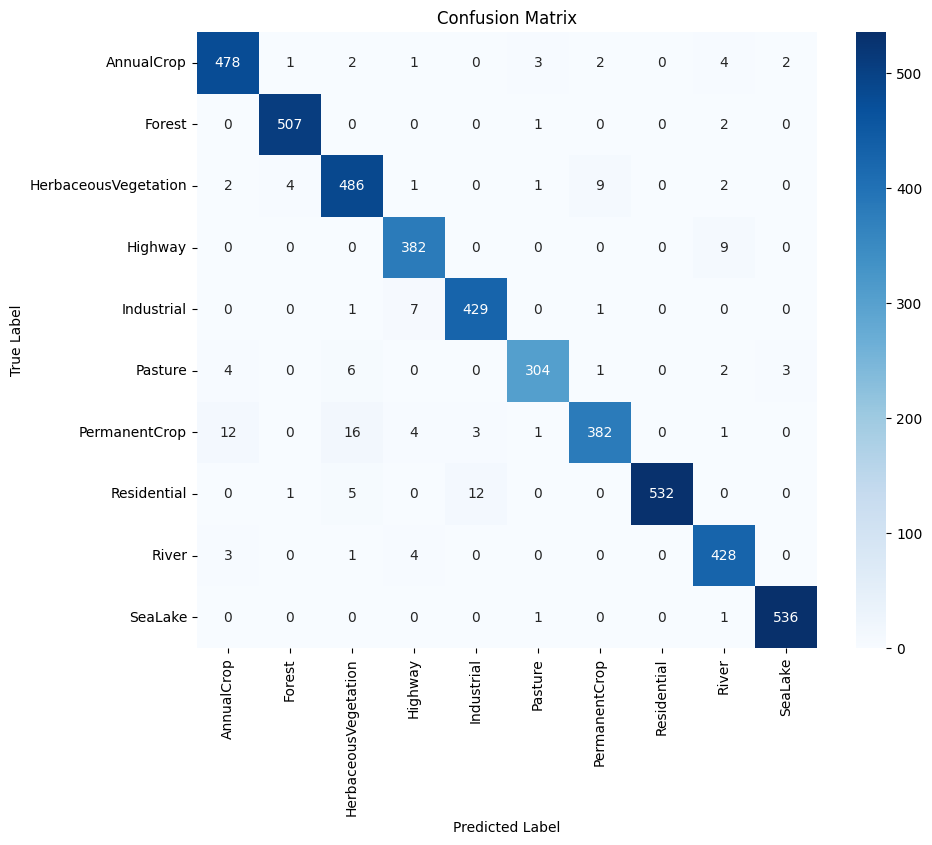

                  Class  Per-Class Accuracy (%)
0            AnnualCrop               96.957404
1                Forest               99.411765
2  HerbaceousVegetation               96.237624
3               Highway               97.698210
4            Industrial               97.945205
5               Pasture               95.000000
6         PermanentCrop               91.169451
7           Residential               96.727273
8                 River               98.165138
9               SeaLake               99.628253


In [ ]:
class_names = train_dataset_full.classes

cm_cnn, acc_cnn = evaluate_model(model,"best_eurosat_model.pth", val_dataloader,class_names)

# Frozen Backbone Model

In [ ]:
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn

frozen_model = resnet18(weights=ResNet18_Weights.DEFAULT)

for param in frozen_model.parameters():
    param.requires_grad = False

frozen_model.fc = nn.Sequential(nn.Linear(frozen_model.fc.in_features,256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256,10))

frozen_model = frozen_model.to(device)
loss_fn_frozen = nn.CrossEntropyLoss()
optimizer_frozen = torch.optim.AdamW(frozen_model.fc.parameters(),lr=1e-3,weight_decay=1e-4)
scheduler_frozen = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_frozen,mode="max",factor=0.5,patience=2)

In [ ]:
frozen_train_losses = []
frozen_val_losses = []
frozen_val_accs = []

best_acc_frozen = 0
epochs = 20

for epoch in range(epochs):

    train_loss = train_loop(resnet_train_dataloader,frozen_model,loss_fn_frozen,optimizer_frozen)
    val_loss, val_acc = validation_loop(resnet_val_dataloader,frozen_model,loss_fn_frozen)

    scheduler_frozen.step(val_acc)

    frozen_train_losses.append(train_loss)
    frozen_val_losses.append(val_loss)
    frozen_val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {100*val_acc:.2f}%"
    )

    if val_acc > best_acc_frozen:
        best_acc_frozen = val_acc
        torch.save(frozen_model.state_dict(),"best_frozen_resnet18.pth")
        print("Best frozen model saved.")

Epoch 1/20 | Train Loss: 0.6921 | Val Loss: 0.4927 | Val Acc: 82.85%
Best frozen model saved.
Epoch 2/20 | Train Loss: 0.4382 | Val Loss: 0.3401 | Val Acc: 88.33%
Best frozen model saved.
Epoch 3/20 | Train Loss: 0.3829 | Val Loss: 0.3688 | Val Acc: 87.93%
Epoch 4/20 | Train Loss: 0.3654 | Val Loss: 0.3213 | Val Acc: 88.54%
Best frozen model saved.
Epoch 5/20 | Train Loss: 0.3635 | Val Loss: 0.4191 | Val Acc: 85.22%
Epoch 6/20 | Train Loss: 0.3490 | Val Loss: 0.3378 | Val Acc: 88.72%
Best frozen model saved.
Epoch 7/20 | Train Loss: 0.3339 | Val Loss: 0.3490 | Val Acc: 87.59%
Epoch 8/20 | Train Loss: 0.3279 | Val Loss: 0.3095 | Val Acc: 89.02%
Best frozen model saved.
Epoch 9/20 | Train Loss: 0.3228 | Val Loss: 0.3327 | Val Acc: 88.24%
Epoch 10/20 | Train Loss: 0.3187 | Val Loss: 0.3222 | Val Acc: 88.57%
Epoch 11/20 | Train Loss: 0.3054 | Val Loss: 0.2724 | Val Acc: 90.67%
Best frozen model saved.
Epoch 12/20 | Train Loss: 0.3014 | Val Loss: 0.2891 | Val Acc: 89.65%
Epoch 13/20 | Train

                      precision    recall  f1-score   support

          AnnualCrop       0.95      0.92      0.93       493
              Forest       0.96      0.96      0.96       510
HerbaceousVegetation       0.91      0.90      0.91       505
             Highway       0.82      0.85      0.84       391
          Industrial       0.92      0.95      0.94       438
             Pasture       0.93      0.88      0.91       320
       PermanentCrop       0.91      0.89      0.90       419
         Residential       0.95      0.97      0.96       550
               River       0.83      0.87      0.85       436
             SeaLake       0.98      0.96      0.97       538

            accuracy                           0.92      4600
           macro avg       0.92      0.92      0.92      4600
        weighted avg       0.92      0.92      0.92      4600



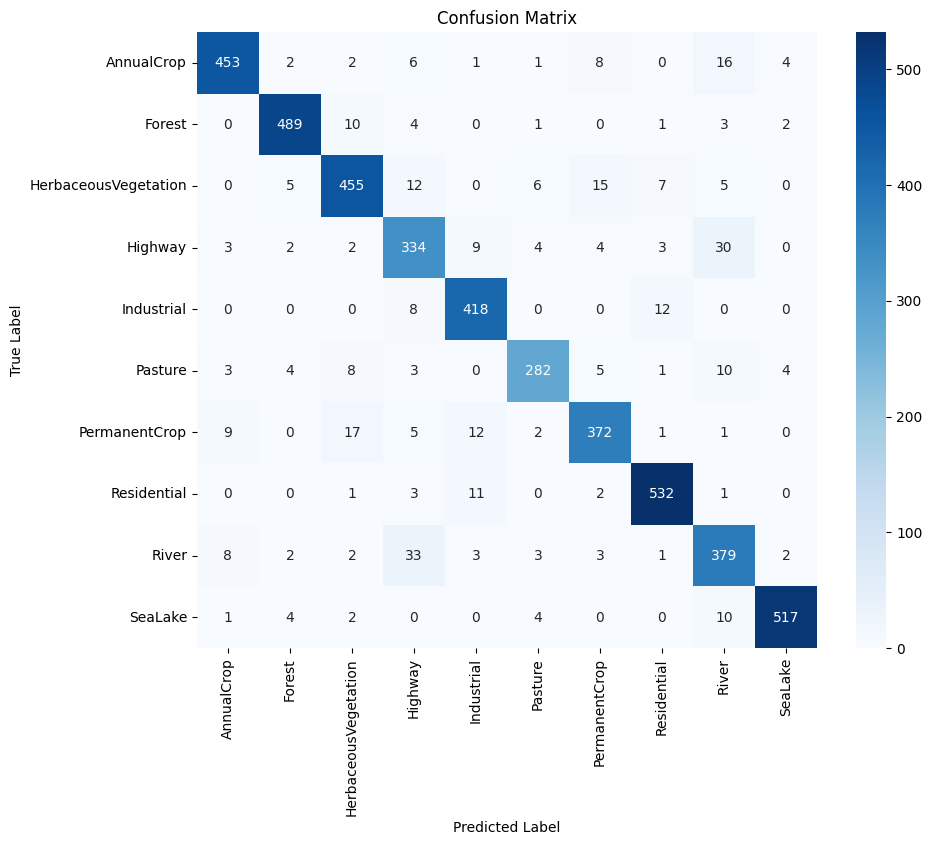

                  Class  Per-Class Accuracy (%)
0            AnnualCrop               91.886410
1                Forest               95.882353
2  HerbaceousVegetation               90.099010
3               Highway               85.421995
4            Industrial               95.433790
5               Pasture               88.125000
6         PermanentCrop               88.782816
7           Residential               96.727273
8                 River               86.926606
9               SeaLake               96.096654


In [ ]:
cm_frozen, acc_frozen = evaluate_model(frozen_model,"best_frozen_resnet18.pth",resnet_val_dataloader,class_names)

# Full-Model Fine Tuning

In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

ft_model = resnet18(weights=ResNet18_Weights.DEFAULT)

ft_model.fc = nn.Linear(ft_model.fc.in_features,10)

ft_model = ft_model.to(device)

In [ ]:
trainable_params = sum(p.numel() for p in ft_model.parameters()if p.requires_grad)
print(f"Trainable Parameters: {trainable_params:,}")

Trainable Parameters: 11,181,642


In [ ]:
loss_fn_ft = nn.CrossEntropyLoss()

optimizer_ft = torch.optim.AdamW(ft_model.parameters(),lr=1e-4,weight_decay=1e-4)

scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft,mode="max",factor=0.5,patience=2)

In [ ]:
ft_train_losses = []
ft_val_losses = []
ft_val_accs = []

best_acc_ft = 0
epochs = 20

for epoch in range(epochs):
    train_loss = train_loop(resnet_train_dataloader,ft_model,loss_fn_ft,optimizer_ft)
    val_loss, val_acc = validation_loop(resnet_val_dataloader,ft_model,loss_fn_ft)

    scheduler_ft.step(val_acc)
    ft_train_losses.append(train_loss)
    ft_val_losses.append(val_loss)
    ft_val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {100*val_acc:.2f}%"
    )

    if val_acc > best_acc_ft:
        best_acc_ft = val_acc
        torch.save(ft_model.state_dict(),"best_ft_resnet18.pth")
        print("Best fine-tuned model saved.")

Epoch 1/20 | Train Loss: 0.2710 | Val Loss: 0.1005 | Val Acc: 96.59%
Best fine-tuned model saved.
Epoch 2/20 | Train Loss: 0.1193 | Val Loss: 0.0762 | Val Acc: 97.41%
Best fine-tuned model saved.
Epoch 3/20 | Train Loss: 0.0997 | Val Loss: 0.0760 | Val Acc: 97.02%
Epoch 4/20 | Train Loss: 0.0813 | Val Loss: 0.0763 | Val Acc: 97.28%
Epoch 5/20 | Train Loss: 0.0728 | Val Loss: 0.0887 | Val Acc: 97.07%
Epoch 6/20 | Train Loss: 0.0466 | Val Loss: 0.0466 | Val Acc: 98.13%
Best fine-tuned model saved.
Epoch 7/20 | Train Loss: 0.0414 | Val Loss: 0.0537 | Val Acc: 97.89%
Epoch 8/20 | Train Loss: 0.0361 | Val Loss: 0.0555 | Val Acc: 98.15%
Best fine-tuned model saved.
Epoch 9/20 | Train Loss: 0.0383 | Val Loss: 0.0439 | Val Acc: 98.50%
Best fine-tuned model saved.
Epoch 10/20 | Train Loss: 0.0346 | Val Loss: 0.0514 | Val Acc: 98.24%
Epoch 11/20 | Train Loss: 0.0318 | Val Loss: 0.0449 | Val Acc: 98.43%
Epoch 12/20 | Train Loss: 0.0264 | Val Loss: 0.0489 | Val Acc: 98.37%
Epoch 13/20 | Train Loss

                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.99      0.98       493
              Forest       1.00      1.00      1.00       510
HerbaceousVegetation       0.99      0.97      0.98       505
             Highway       0.98      0.99      0.99       391
          Industrial       1.00      0.98      0.99       438
             Pasture       0.98      0.97      0.98       320
       PermanentCrop       0.97      0.98      0.98       419
         Residential       1.00      1.00      1.00       550
               River       0.99      0.99      0.99       436
             SeaLake       1.00      1.00      1.00       538

            accuracy                           0.99      4600
           macro avg       0.99      0.99      0.99      4600
        weighted avg       0.99      0.99      0.99      4600



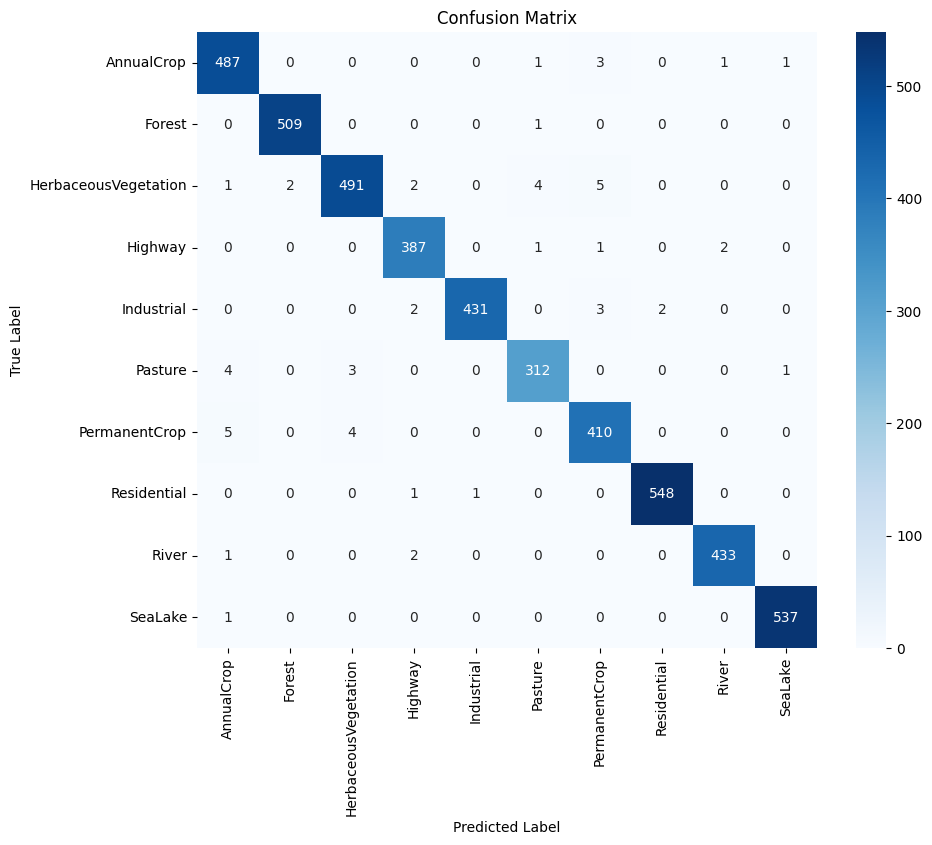

                  Class  Per-Class Accuracy (%)
0            AnnualCrop               98.782961
1                Forest               99.803922
2  HerbaceousVegetation               97.227723
3               Highway               98.976982
4            Industrial               98.401826
5               Pasture               97.500000
6         PermanentCrop               97.852029
7           Residential               99.636364
8                 River               99.311927
9               SeaLake               99.814126


In [ ]:
cm_ft, acc_ft = evaluate_model(ft_model,"best_ft_resnet18.pth",resnet_val_dataloader,class_names)

# Final Comparison

In [ ]:
print(f"CNN Scratch      : {100*max(cnn_val_accs):.2f}%")
print(f"Frozen Backbone  : {100*max(frozen_val_accs):.2f}%")
print(f"Fine-Tuned       : {100*max(ft_val_accs):.2f}%")

CNN Scratch      : 97.04%
Frozen Backbone  : 91.98%
Fine-Tuned       : 98.80%


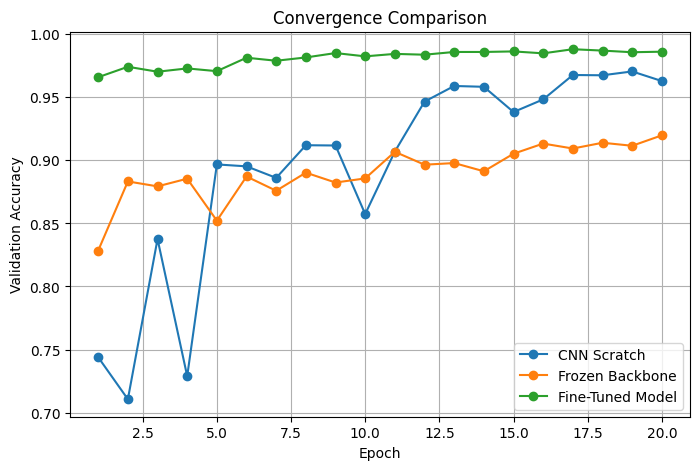

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    range(1, len(cnn_val_accs)+1),
    cnn_val_accs,
    marker="o",
    label="CNN Scratch"
)

plt.plot(
    range(1, len(frozen_val_accs)+1),
    frozen_val_accs,
    marker="o",
    label="Frozen Backbone"
)

plt.plot(
    range(1, len(ft_val_accs)+1),
    ft_val_accs,
    marker="o",
    label="Fine-Tuned Model"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Convergence Comparison")
plt.legend()
plt.grid(True)

plt.show()

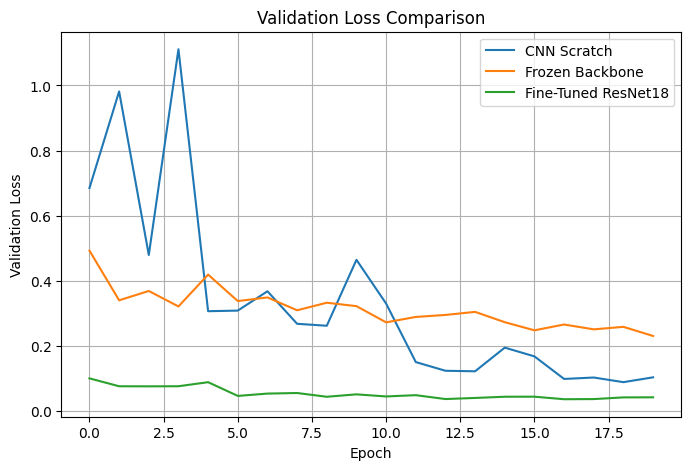

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(cnn_val_losses,label="CNN Scratch")
plt.plot(frozen_val_losses,label="Frozen Backbone")
plt.plot(ft_val_losses,label="Fine-Tuned ResNet18")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
def epoch_to_threshold(acc_list, threshold):
    for epoch, acc in enumerate(acc_list, start=1):
        if acc >= threshold:
            return epoch
    return None

In [ ]:
print("Epoch to reach 90% accuracy")

print(
    "CNN Scratch:",
    epoch_to_threshold(cnn_val_accs,0.9)
)

print(
    "Frozen Backbone:",
    epoch_to_threshold(frozen_val_accs,0.9)
)

print(
    "Fine-Tuned ResNet18:",
    epoch_to_threshold(ft_val_accs,0.9)
)

Epoch to reach 90% accuracy
CNN Scratch: 8
Frozen Backbone: 11
Fine-Tuned ResNet18: 1


In [ ]:
comparison_df = pd.DataFrame({
    "Model": [
        "CNN Scratch",
        "Frozen Backbone",
        "Fine-Tuned ResNet18"
    ],
    "Best Validation Accuracy (%)": [
        100*max(cnn_val_accs),
        100*max(frozen_val_accs),
        100*max(ft_val_accs)
    ]
})

comparison_df

,Model,Best Validation Accuracy (%)
0,CNN Scratch,97.043478
1,Frozen Backbone,91.978261
2,Fine-Tuned ResNet18,98.804348


In [ ]:
from google.colab import files

print("Upload test.zip")
uploaded = files.upload()

with zipfile.ZipFile("test.zip", "r") as z:
    z.extractall("test_data")

Upload test.zip


Saving test.zip to test.zip


In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import os

class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_names = sorted(os.listdir(root_dir))

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_name = self.image_names[idx]

        image_path = os.path.join(
            self.root_dir,
            image_name
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, image_name


resnet_test_dataset = TestDataset(
    root_dir="test_data/test_set",
    transform=resnet_val_transform
)

resnet_test_dataloader = DataLoader(
    resnet_test_dataset,
    batch_size=64,
    shuffle=False
)

In [ ]:
frozen_model.load_state_dict(
    torch.load(
        "best_frozen_resnet18.pth",
        weights_only=True
    )
)

frozen_model.eval()

image_ids = []
predicted_labels = []

with torch.no_grad():

    for images, names in resnet_test_dataloader:

        images = images.to(device)

        outputs = frozen_model(images)

        preds = outputs.argmax(dim=1)

        image_ids.extend(names)

        predicted_labels.extend(
            preds.cpu().numpy()
        )

submission_frozen = pd.DataFrame({
    "img_id": image_ids,
    "label": predicted_labels
})

submission_frozen.to_csv(
    "submission_frozen.csv",
    index=False
)

print(submission_frozen.head())

files.download("submission_frozen.csv")

          img_id  label
0  img_00000.jpg      9
1  img_00001.jpg      2
2  img_00002.jpg      3
3  img_00003.jpg      2
4  img_00004.jpg      5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
ft_model.load_state_dict(
    torch.load(
        "best_ft_resnet18.pth",
        weights_only=True
    )
)

ft_model.eval()

image_ids = []
predicted_labels = []

with torch.no_grad():

    for images, names in resnet_test_dataloader:

        images = images.to(device)

        outputs = ft_model(images)

        preds = outputs.argmax(dim=1)

        image_ids.extend(names)

        predicted_labels.extend(
            preds.cpu().numpy()
        )

submission_ft = pd.DataFrame({
    "img_id": image_ids,
    "label": predicted_labels
})

submission_ft.to_csv(
    "submission_finetuned.csv",
    index=False
)

print(submission_ft.head())

files.download("submission_finetuned.csv")

          img_id  label
0  img_00000.jpg      9
1  img_00001.jpg      3
2  img_00002.jpg      3
3  img_00003.jpg      2
4  img_00004.jpg      5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("submission_frozen.csv")
files.download("submission_finetuned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>